# 지역별 기온 트렌드 분석

대전, 서울, 부산, 제주 4개 지역의 일별 기온 데이터를 비교 분석합니다.

## 분석 질문 (직접 채워보세요)
1. 2022년부터 2026년까지 전체적으로 평균 기온이 상승하는 추세가 있는가?
2. 4개 지역 중 연교차(여름과 겨울 기온 차이)가 가장 큰 지역과 작은 지역은 어디인가?
3. 4개 지역 모두에서 특별히 이상 고온/저온이 발생한 날(구간)이 있는가? 있다면 언제인가?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트, Mac이면 'AppleGothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False


## 1. 데이터 불러오기

Open-Meteo CSV는 앞부분에 위치/시간대 메타데이터가 몇 줄 포함되어 있습니다.
`time`으로 시작하는 줄을 자동으로 찾아 헤더로 사용하는 함수를 만들어 사용합니다.

In [2]:
def load_open_meteo_csv(filepath, region_name):
    with open(filepath, encoding='utf-8') as f:
        lines = f.readlines()
    header_idx = next(i for i, line in enumerate(lines) if line.startswith('time'))
    df = pd.read_csv(filepath, skiprows=header_idx)
    df['region'] = region_name
    return df

files = {
    '대전': 'data/daejeon_weather_2022_2026.csv',
    '서울': 'data/seoul_weather_2022_2026.csv',
    '부산': 'data/busan_weather_2022_2026.csv',
    '제주': 'data/jeju_weather_2022_2026.csv',
}

dfs = [load_open_meteo_csv(path, region) for region, path in files.items()]
df = pd.concat(dfs, ignore_index=True)
df.columns = [col.split(' (')[0] for col in df.columns]   # ← 이 줄 추가
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['region', 'time']).reset_index(drop=True)

print("데이터 형태:", df.shape)
print("\n컬럼 목록:", df.columns.tolist())
df.head()

데이터 형태: (6808, 6)

컬럼 목록: ['time', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'precipitation_sum', 'region']


,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,region
0,2022-01-01,1.3,-8.0,-4.0,0.0,대전
1,2022-01-02,6.4,-5.0,-0.9,0.0,대전
2,2022-01-03,3.7,-6.4,-2.0,0.0,대전
3,2022-01-04,3.2,-5.0,-0.8,0.0,대전
4,2022-01-05,5.2,-5.9,-0.8,0.0,대전


## 2. 데이터 기본 정보 및 결측치/이상치 확인

In [3]:
print("기간:", df['time'].min(), "~", df['time'].max())
print("\n지역별 데이터 개수:")
print(df['region'].value_counts())
print("\n결측치 개수:")
print(df.isnull().sum())
print("\n기술통계:")
df.describe()

기간: 2022-01-01 00:00:00 ~ 2026-08-29 00:00:00

지역별 데이터 개수:
region
대전    1702
부산    1702
서울    1702
제주    1702
Name: count, dtype: int64

결측치 개수:
time                   0
temperature_2m_max     0
temperature_2m_min     0
temperature_2m_mean    0
precipitation_sum      0
region                 0
dtype: int64

기술통계:


,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum
count,6808,6808.000000,6808.000000,6808.000000,6808.000000
mean,2024-04-30 12:00:00,18.844183,10.538969,14.415526,4.300441
min,2022-01-01 00:00:00,-10.100000,-18.500000,-14.900000,0.000000
25%,2023-03-02 00:00:00,10.700000,2.000000,6.200000,0.000000
50%,2024-04-30 12:00:00,20.100000,10.900000,15.300000,0.100000
75%,2025-06-30 00:00:00,27.200000,20.000000,23.300000,2.600000
max,2026-08-29 00:00:00,40.200000,29.400000,34.100000,183.500000
std,NaN,9.845578,10.408938,9.989004,11.887381


In [4]:
# TODO: 결측치/이상치가 발견되면 처리 기준을 정하고 아래에 적용
# 예시: 결측치가 있는 행 제거
# df = df.dropna(subset=['temperature_2m_mean'])

# 처리 전/후 비교를 통해 몇 개가 처리되었는지 기록해두면 리포트에 쓰기 좋습니다.


## 3. 시계열 분석 기법 적용

이동평균과 월별 통계 두 가지를 적용합니다.

In [5]:
# 3-1. 이동평균 (7일, 30일)
df = df.sort_values(['region', 'time'])
df['ma7'] = df.groupby('region')['temperature_2m_mean'].transform(lambda x: x.rolling(7).mean())
df['ma30'] = df.groupby('region')['temperature_2m_mean'].transform(lambda x: x.rolling(30).mean())

# 3-2. 월별 평균 기온
df['year_month'] = df['time'].dt.to_period('M')
monthly = df.groupby(['region', 'year_month'])['temperature_2m_mean'].mean().reset_index()
monthly.head()

,region,year_month,temperature_2m_mean
0,대전,2022-01,-1.238710
1,대전,2022-02,-0.450000
2,대전,2022-03,7.590323
3,대전,2022-04,14.196667
4,대전,2022-05,19.035484


## 4. 시각화

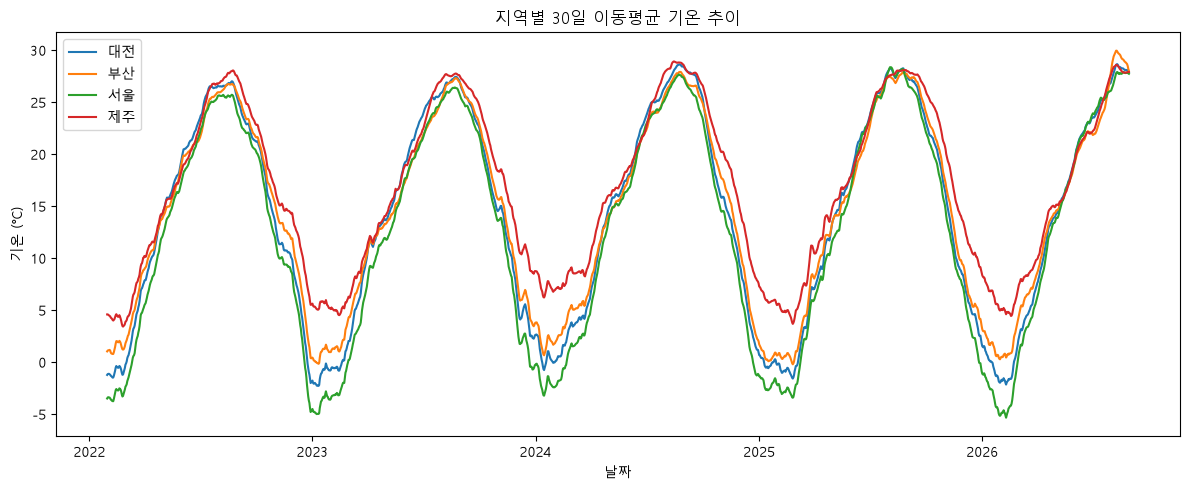

In [6]:
import os
os.makedirs('images', exist_ok=True)

# 시각화 1: 지역별 30일 이동평균 기온 추이
fig, ax = plt.subplots(figsize=(12, 5))
for region in df['region'].unique():
    sub = df[df['region'] == region]
    ax.plot(sub['time'], sub['ma30'], label=region)
ax.set_title('지역별 30일 이동평균 기온 추이')
ax.set_xlabel('날짜')
ax.set_ylabel('기온 (°C)')
ax.legend()
plt.tight_layout()
plt.savefig('images/01_region_trend.png', dpi=150)
plt.show()

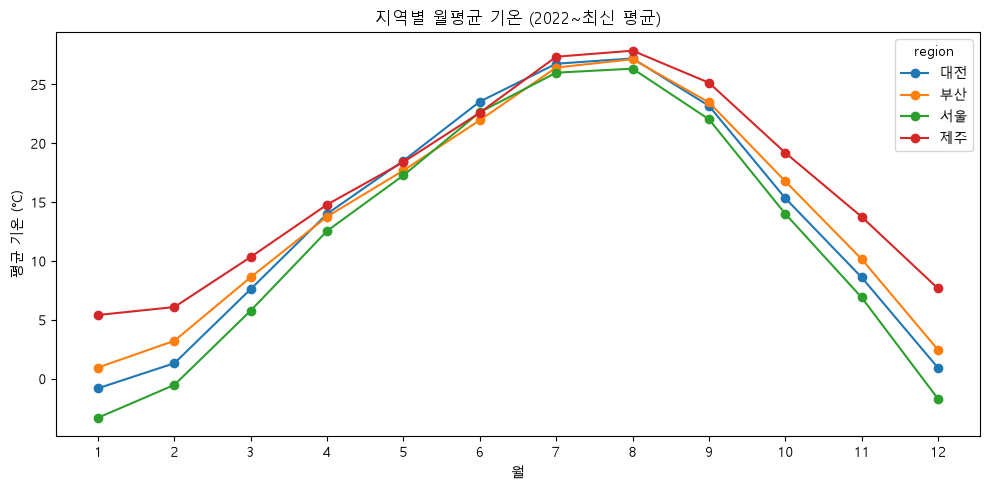

In [7]:
# 시각화 2: 지역별 월별 평균 기온 히트맵 느낌의 라인
monthly_pivot = df.groupby(['region', df['time'].dt.month])['temperature_2m_mean'].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(10, 5))
monthly_pivot.plot(ax=ax, marker='o')
ax.set_title('지역별 월평균 기온 (2022~최신 평균)')
ax.set_xlabel('월')
ax.set_ylabel('평균 기온 (°C)')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.savefig('images/02_monthly_avg_by_region.png', dpi=150)
plt.show()

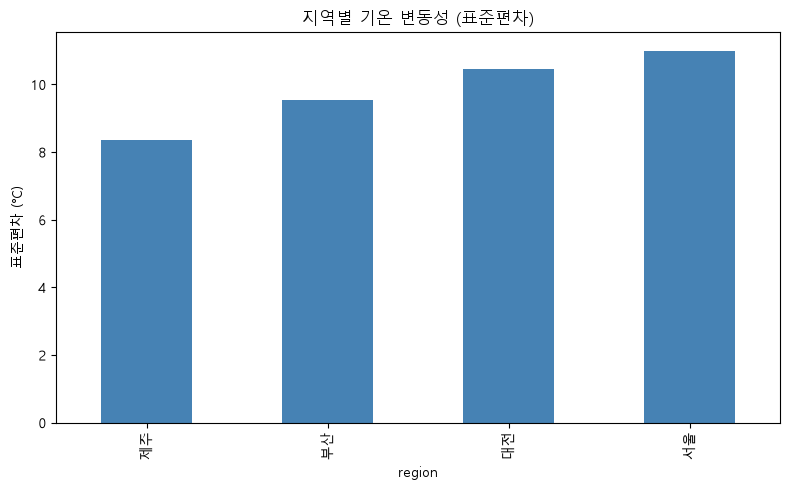

In [8]:
# 시각화 3 (권장): 지역별 기온 변동성(표준편차) 비교
volatility = df.groupby('region')['temperature_2m_mean'].std().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
volatility.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('지역별 기온 변동성 (표준편차)')
ax.set_ylabel('표준편차 (°C)')
plt.tight_layout()
plt.savefig('images/03_volatility_by_region.png', dpi=150)
plt.show()

## 5. 인사이트 (직접 작성)

위 그래프에서 확인한 **관찰(수치/근거)**과 그에 대한 **해석(가설)**을 구분해서 3개 이상 적어보세요.

### 인사이트 1
- 관찰(Fact): 1월 기준 서울은 평균 약 -3°C, 제주는 약 5.4°C로 두 지역 간 약 8.4°C 차이가 났다. 반면 7~8월 여름철에는 4개 지역 모두 26~28°C 사이로 좁혀지며 지역 차이가 2°C 이내로 크게 줄어들었다.
- 해석(가설): 겨울철에는 위도와 해양성/대륙성 기후 차이가 뚜렷하게 드러나지만, 여름철에는 남한 전역이 비슷한 고온다습한 기단의 영향을 받아 지역 간 차이가 상대적으로 작아지는 것으로 보인다.
- 다음 행동/제안: 습도나 강수량 데이터를 함께 보면 여름철 "기온은 비슷해도 체감은 다를 수 있다"는 가설을 추가로 검증할 수 있을 것이다.

### 인사이트 2
- 관찰(Fact): 기온 표준편차는 서울이 약 10.95°C로 가장 높았고, 제주가 약 8.35°C로 가장 낮았다. 대전(10.45°C)과 부산(9.5°C)은 그 중간에 위치했다.
- 해석(가설): 서울은 내륙에 위치해 여름·겨울 기온차가 크게 나타나는 대륙성 기후 특성을 보이는 반면, 제주는 바다로 둘러싸여 있어 연중 기온이 비교적 완만하게 유지되는 해양성 기후 특성이 반영된 것으로 보인다.
- 다음 행동/제안: 계절별(겨울 vs 여름)로 표준편차를 나눠서 계산해보면, 이 차이가 주로 겨울철 저온 구간에서 발생하는지 확인할 수 있을 것이다.

### 인사이트 3
- 관찰(Fact): 2022년부터 최근까지 매년 여름 정점은 대체로 27~29°C 구간에서 반복되었고, 겨울 저점도 -5~0°C 구간에서 유사하게 나타나 뚜렷한 상승/하락 추세는 육안으로는 크게 두드러지지 않았다. 다만 가장 최근 구간(2026년 여름)의 피크가 이전 연도들보다 다소 높게(약 29~30°C) 나타났다.
- 해석(가설): 4~5년 정도의 짧은 기간으로는 뚜렷한 온난화 추세를 단정하기 어렵고, 최근 여름의 높은 피크는 특정 해의 이상 고온 현상일 가능성도 있다.
- 다음 행동/제안: 10년 이상의 장기 데이터를 추가로 확보해 같은 방식으로 재분석하면, 이번 관찰이 일시적 현상인지 실제 추세인지 더 명확히 구분할 수 있을 것이다.

In [9]:
# 통합 데이터 저장 (Streamlit 대시보드에서 재사용)
df.to_csv('data/combined_weather.csv', index=False)
print("저장 완료: data/combined_weather.csv")

저장 완료: data/combined_weather.csv
